# Before you start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [131]:
# Importar las bibliotecas necesarias
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



In this lab, we will explore a dataset that describes websites with different features and labels them either benign or malicious . We will use supervised learning algorithms to figure out what feature patterns malicious websites are likely to have and use our model to predict malicious websites.

# Challenge 1 - Explore The Dataset

Let's start by exploring the dataset. First load the data file:

In [132]:
websites = pd.read_csv('../data/website.csv')

#### Explore the data from an bird's-eye view.

You should already been very familiar with the procedures now so we won't provide the instructions step by step. Reflect on what you did in the previous labs and explore the dataset.

Things you'll be looking for:

* What the dataset looks like?
* What are the data types?
* Which columns contain the features of the websites?
* Which column contains the feature we will predict? What is the code standing for benign vs malicious websites?
* Do we need to transform any of the columns from categorical to ordinal values? If so what are these columns?

Feel free to add additional cells for more exploration. Make sure to comment what you find!

In [133]:
websites.head(10)


,URL,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CHARSET,SERVER,CONTENT_LENGTH,WHOIS_COUNTRY,WHOIS_STATEPRO,WHOIS_REGDATE,WHOIS_UPDATED_DATE,...,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
0,M0_109,16,7,iso-8859-1,nginx,263.0,NaN,NaN,10/10/2015 18:21,NaN,...,0,2,700,9,10,1153,832,9,2.0,1
1,B0_2314,16,6,UTF-8,Apache/2.4.10,15087.0,NaN,NaN,NaN,NaN,...,7,4,1230,17,19,1265,1230,17,0.0,0
2,B0_911,16,6,us-ascii,Microsoft-HTTPAPI/2.0,324.0,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0.0,0
3,B0_113,17,6,ISO-8859-1,nginx,162.0,US,AK,7/10/1997 4:00,12/09/2013 0:45,...,22,3,3812,39,37,18784,4380,39,8.0,0
4,B0_403,17,6,UTF-8,NaN,124140.0,US,TX,12/05/1996 0:00,11/04/2017 0:00,...,2,5,4278,61,62,129889,4586,61,4.0,0
5,B0_2064,18,7,UTF-8,nginx,NaN,SC,Mahe,3/08/2016 14:30,3/10/2016 3:45,...,6,9,894,11,13,838,894,11,0.0,0
6,B0_462,18,6,iso-8859-1,Apache/2,345.0,US,CO,29/07/2002 0:00,1/07/2016 0:00,...,0,3,1189,14,13,8559,1327,14,2.0,0
7,B0_1128,19,6,us-ascii,Microsoft-HTTPAPI/2.0,324.0,US,FL,18/03/1997 0:00,19/03/2017 0:00,...,0,0,0,0,0,0,0,0,0.0,0
8,M2_17,20,5,utf-8,nginx/1.10.1,NaN,NaN,NaN,8/11/2014 7:41,NaN,...,0,0,0,2,3,213,146,2,2.0,1
9,M3_75,20,5,utf-8,nginx/1.10.1,NaN,NaN,NaN,8/11/2014 7:41,NaN,...,0,0,0,2,1,62,146,2,2.0,1


In [134]:
websites

,URL,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CHARSET,SERVER,CONTENT_LENGTH,WHOIS_COUNTRY,WHOIS_STATEPRO,WHOIS_REGDATE,WHOIS_UPDATED_DATE,...,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
0,M0_109,16,7,iso-8859-1,nginx,263.0,NaN,NaN,10/10/2015 18:21,NaN,...,0,2,700,9,10,1153,832,9,2.0,1
1,B0_2314,16,6,UTF-8,Apache/2.4.10,15087.0,NaN,NaN,NaN,NaN,...,7,4,1230,17,19,1265,1230,17,0.0,0
2,B0_911,16,6,us-ascii,Microsoft-HTTPAPI/2.0,324.0,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0.0,0
3,B0_113,17,6,ISO-8859-1,nginx,162.0,US,AK,7/10/1997 4:00,12/09/2013 0:45,...,22,3,3812,39,37,18784,4380,39,8.0,0
4,B0_403,17,6,UTF-8,NaN,124140.0,US,TX,12/05/1996 0:00,11/04/2017 0:00,...,2,5,4278,61,62,129889,4586,61,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,M4_48,194,16,UTF-8,Apache,NaN,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,...,0,0,0,0,3,186,0,0,0.0,1
1777,M4_41,198,17,UTF-8,Apache,NaN,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,...,0,0,0,0,2,124,0,0,0.0,1
1778,B0_162,201,34,utf-8,Apache/2.2.16 (Debian),8904.0,US,FL,15/02/1999 0:00,15/07/2015 0:00,...,2,6,6631,87,89,132181,6945,87,4.0,0
1779,B0_1152,234,34,ISO-8859-1,cloudflare-nginx,NaN,US,CA,1/04/1998 0:00,9/12/2016 0:00,...,0,0,0,0,0,0,0,0,0.0,0


In [135]:
websites.tail(20)

,URL,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CHARSET,SERVER,CONTENT_LENGTH,WHOIS_COUNTRY,WHOIS_STATEPRO,WHOIS_REGDATE,WHOIS_UPDATED_DATE,...,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
1761,M4_57,146,28,UTF-8,Apache,NaN,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,...,0,0,0,0,2,124,0,0,0.0,1
1762,B0_221,146,24,UTF-8,nginx,11833.0,US,Arizona,13/07/1998 0:00,28/03/2017 0:00,...,20,8,4167,33,33,3181,4499,33,4.0,0
1763,B0_1361,149,23,ISO-8859-1,NaN,6748.0,CA,Quebec,8/01/1997 0:00,2/06/2009 0:00,...,0,0,0,0,0,0,0,0,0.0,0
1764,M4_35,150,26,UTF-8,Apache,NaN,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,...,0,0,0,0,3,186,0,0,0.0,1
1765,M4_54,151,29,UTF-8,Apache,NaN,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,...,0,0,0,0,3,186,0,0,0.0,1
1766,B0_755,154,21,UTF-8,NaN,11104.0,US,UT,29/07/1998 4:00,17/03/2016 4:34,...,10,8,3764,41,23,7356,4412,41,8.0,0
1767,M4_62,156,31,UTF-8,Apache,NaN,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,...,1,1,90,1,5,416,90,1,0.0,1
1768,B0_62,160,29,UTF-8,NaN,36829.0,US,CA,14/08/1997 0:00,14/06/2016 0:00,...,3,7,2402,25,22,4491,2900,25,6.0,0
1769,B0_2237,161,23,iso-8859-1,Apache/2.4.18 (Ubuntu),417.0,NaN,NaN,23/11/2010 0:00,20/11/2015 0:00,...,7,2,582,7,11,752,582,7,0.0,0
1770,B0_2099,169,25,utf-8,cloudflare-nginx,NaN,BS,New Providence,20/12/2008 0:00,11/12/2015 0:00,...,3,4,552,6,9,564,552,6,0.0,0


In [136]:
websites.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL                        1781 non-null   object 
 1   URL_LENGTH                 1781 non-null   int64  
 2   NUMBER_SPECIAL_CHARACTERS  1781 non-null   int64  
 3   CHARSET                    1774 non-null   object 
 4   SERVER                     1605 non-null   object 
 5   CONTENT_LENGTH             969 non-null    float64
 6   WHOIS_COUNTRY              1475 non-null   object 
 7   WHOIS_STATEPRO             1419 non-null   object 
 8   WHOIS_REGDATE              1654 non-null   object 
 9   WHOIS_UPDATED_DATE         1642 non-null   object 
 10  TCP_CONVERSATION_EXCHANGE  1781 non-null   int64  
 11  DIST_REMOTE_TCP_PORT       1781 non-null   int64  
 12  REMOTE_IPS                 1781 non-null   int64  
 13  APP_BYTES                  1781 non-null   int64

In [137]:
websites.describe()


,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CONTENT_LENGTH,TCP_CONVERSATION_EXCHANGE,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
count,1781.000000,1781.000000,969.000000,1781.000000,1781.000000,1781.000000,1.781000e+03,1781.000000,1781.000000,1.781000e+03,1.781000e+03,1781.000000,1780.000000,1781.000000
mean,56.961258,11.111735,11726.927761,16.261089,5.472768,3.060640,2.982339e+03,18.540146,18.746210,1.589255e+04,3.155599e+03,18.540146,2.263483,0.121280
std,27.555586,4.549896,36391.809051,40.500975,21.807327,3.386975,5.605057e+04,41.627173,46.397969,6.986193e+04,5.605378e+04,41.627173,2.930853,0.326544
min,16.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,39.000000,8.000000,324.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
50%,49.000000,10.000000,1853.000000,7.000000,0.000000,2.000000,6.720000e+02,8.000000,9.000000,5.790000e+02,7.350000e+02,8.000000,0.000000,0.000000
75%,68.000000,13.000000,11323.000000,22.000000,5.000000,5.000000,2.328000e+03,26.000000,25.000000,9.806000e+03,2.701000e+03,26.000000,4.000000,0.000000
max,249.000000,43.000000,649263.000000,1194.000000,708.000000,17.000000,2.362906e+06,1198.000000,1284.000000,2.060012e+06,2.362906e+06,1198.000000,20.000000,1.000000


In [138]:
# Verificar valores faltantes
websites.isnull().sum()


URL                            0
URL_LENGTH                     0
NUMBER_SPECIAL_CHARACTERS      0
CHARSET                        7
SERVER                       176
CONTENT_LENGTH               812
WHOIS_COUNTRY                306
WHOIS_STATEPRO               362
WHOIS_REGDATE                127
WHOIS_UPDATED_DATE           139
TCP_CONVERSATION_EXCHANGE      0
DIST_REMOTE_TCP_PORT           0
REMOTE_IPS                     0
APP_BYTES                      0
SOURCE_APP_PACKETS             0
REMOTE_APP_PACKETS             0
SOURCE_APP_BYTES               0
REMOTE_APP_BYTES               0
APP_PACKETS                    0
DNS_QUERY_TIMES                1
Type                           0
dtype: int64

In [139]:
websites.columns

Index(['URL', 'URL_LENGTH', 'NUMBER_SPECIAL_CHARACTERS', 'CHARSET', 'SERVER',
       'CONTENT_LENGTH', 'WHOIS_COUNTRY', 'WHOIS_STATEPRO', 'WHOIS_REGDATE',
       'WHOIS_UPDATED_DATE', 'TCP_CONVERSATION_EXCHANGE',
       'DIST_REMOTE_TCP_PORT', 'REMOTE_IPS', 'APP_BYTES', 'SOURCE_APP_PACKETS',
       'REMOTE_APP_PACKETS', 'SOURCE_APP_BYTES', 'REMOTE_APP_BYTES',
       'APP_PACKETS', 'DNS_QUERY_TIMES', 'Type'],
      dtype='object')

In [140]:
websites.head()

,URL,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CHARSET,SERVER,CONTENT_LENGTH,WHOIS_COUNTRY,WHOIS_STATEPRO,WHOIS_REGDATE,WHOIS_UPDATED_DATE,...,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
0,M0_109,16,7,iso-8859-1,nginx,263.0,NaN,NaN,10/10/2015 18:21,NaN,...,0,2,700,9,10,1153,832,9,2.0,1
1,B0_2314,16,6,UTF-8,Apache/2.4.10,15087.0,NaN,NaN,NaN,NaN,...,7,4,1230,17,19,1265,1230,17,0.0,0
2,B0_911,16,6,us-ascii,Microsoft-HTTPAPI/2.0,324.0,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0.0,0
3,B0_113,17,6,ISO-8859-1,nginx,162.0,US,AK,7/10/1997 4:00,12/09/2013 0:45,...,22,3,3812,39,37,18784,4380,39,8.0,0
4,B0_403,17,6,UTF-8,NaN,124140.0,US,TX,12/05/1996 0:00,11/04/2017 0:00,...,2,5,4278,61,62,129889,4586,61,4.0,0


In [141]:
websites["Type"].value_counts()

Type
0    1565
1     216
Name: count, dtype: int64

In [142]:
type1 = websites[websites["Type"]==1]
type0 = websites[websites["Type"]==0]

In [143]:
type1.head()

,URL,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CHARSET,SERVER,CONTENT_LENGTH,WHOIS_COUNTRY,WHOIS_STATEPRO,WHOIS_REGDATE,WHOIS_UPDATED_DATE,...,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
0,M0_109,16,7,iso-8859-1,nginx,263.0,NaN,NaN,10/10/2015 18:21,NaN,...,0,2,700,9,10,1153,832,9,2.0,1
8,M2_17,20,5,utf-8,nginx/1.10.1,NaN,NaN,NaN,8/11/2014 7:41,NaN,...,0,0,0,2,3,213,146,2,2.0,1
9,M3_75,20,5,utf-8,nginx/1.10.1,NaN,NaN,NaN,8/11/2014 7:41,NaN,...,0,0,0,2,1,62,146,2,2.0,1
15,M0_71,21,7,ISO-8859-1,Apache/2.4.23 (Unix) OpenSSL/1.0.1e-fips mod_b...,957.0,UK,NaN,16/07/2000 0:00,4/07/2015 0:00,...,0,1,717,11,10,1960,1011,11,4.0,1
16,M0_97,21,7,iso-8859-1,nginx,686.0,RU,Novosibirskaya obl.,25/05/2013 0:00,23/05/2016 0:00,...,0,2,603,8,9,1580,745,8,2.0,1


In [144]:
type0.head()

,URL,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CHARSET,SERVER,CONTENT_LENGTH,WHOIS_COUNTRY,WHOIS_STATEPRO,WHOIS_REGDATE,WHOIS_UPDATED_DATE,...,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
1,B0_2314,16,6,UTF-8,Apache/2.4.10,15087.0,NaN,NaN,NaN,NaN,...,7,4,1230,17,19,1265,1230,17,0.0,0
2,B0_911,16,6,us-ascii,Microsoft-HTTPAPI/2.0,324.0,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0.0,0
3,B0_113,17,6,ISO-8859-1,nginx,162.0,US,AK,7/10/1997 4:00,12/09/2013 0:45,...,22,3,3812,39,37,18784,4380,39,8.0,0
4,B0_403,17,6,UTF-8,NaN,124140.0,US,TX,12/05/1996 0:00,11/04/2017 0:00,...,2,5,4278,61,62,129889,4586,61,4.0,0
5,B0_2064,18,7,UTF-8,nginx,NaN,SC,Mahe,3/08/2016 14:30,3/10/2016 3:45,...,6,9,894,11,13,838,894,11,0.0,0


In [145]:
#1. Es un dataset con 1781 filas y 21 columnas, cada fila representa un sito web.
#2. De sus columnas tiene 12 int64 7 object y 2 float64
#3. Todas las columnas contienen informacion del sitio ('URL', 'URL_LENGTH', 'NUMBER_SPECIAL_CHARACTERS', 'CHARSET', 'SERVER',
       #'CONTENT_LENGTH', 'WHOIS_COUNTRY', 'WHOIS_STATEPRO', 'WHOIS_REGDATE','WHOIS_UPDATED_DATE', 'TCP_CONVERSATION_EXCHANGE',
       #'DIST_REMOTE_TCP_PORT', 'REMOTE_IPS', 'APP_BYTES', 'SOURCE_APP_PACKETS','REMOTE_APP_PACKETS', 'SOURCE_APP_BYTES', 'REMOTE_APP_BYTES',
       #'APP_PACKETS', 'DNS_QUERY_TIMES')
#4. La columna type contiene un 1 para el que  es malisioso y 0 para el sito que no, ese seria nuestro target 
# asumimos que el 0 es una pagina segura al saber que la mayoria de los casos estan en dicha opcion y teniendo en cuenta que vamos a tener mas paginas segura que maliciosas 
#5. Cambiaria la fechas a otro formato para el modelo y todas las variables categoricas haria encoding para poder pasarlo por el  modelo
# Tambien vemos que tenemos muchos valores nulos en diferentes columnas donde tendremos que estudiar el caso de cada uno y ver cual es la mejor manera de tratarlo
# 

#### Next, evaluate if the columns in this dataset are strongly correlated.

In class, we discussed that we are concerned if our dataset has strongly correlated columns because if this is the case we need to choose certain ML algorithms instead of others. We need to evaluate this for our dataset now.

Luckily, most of the columns in this dataset are ordinal which makes things a lot easier for us. In the cells below, evaluate the level of collinearity of the data.

We provide some general directions for you to consult in order to complete this step:

1. You will create a correlation matrix using the numeric columns in the dataset.

1. Create a heatmap using `seaborn` to visualize which columns have high collinearity.

1. Comment on which columns you might need to remove due to high collinearity.

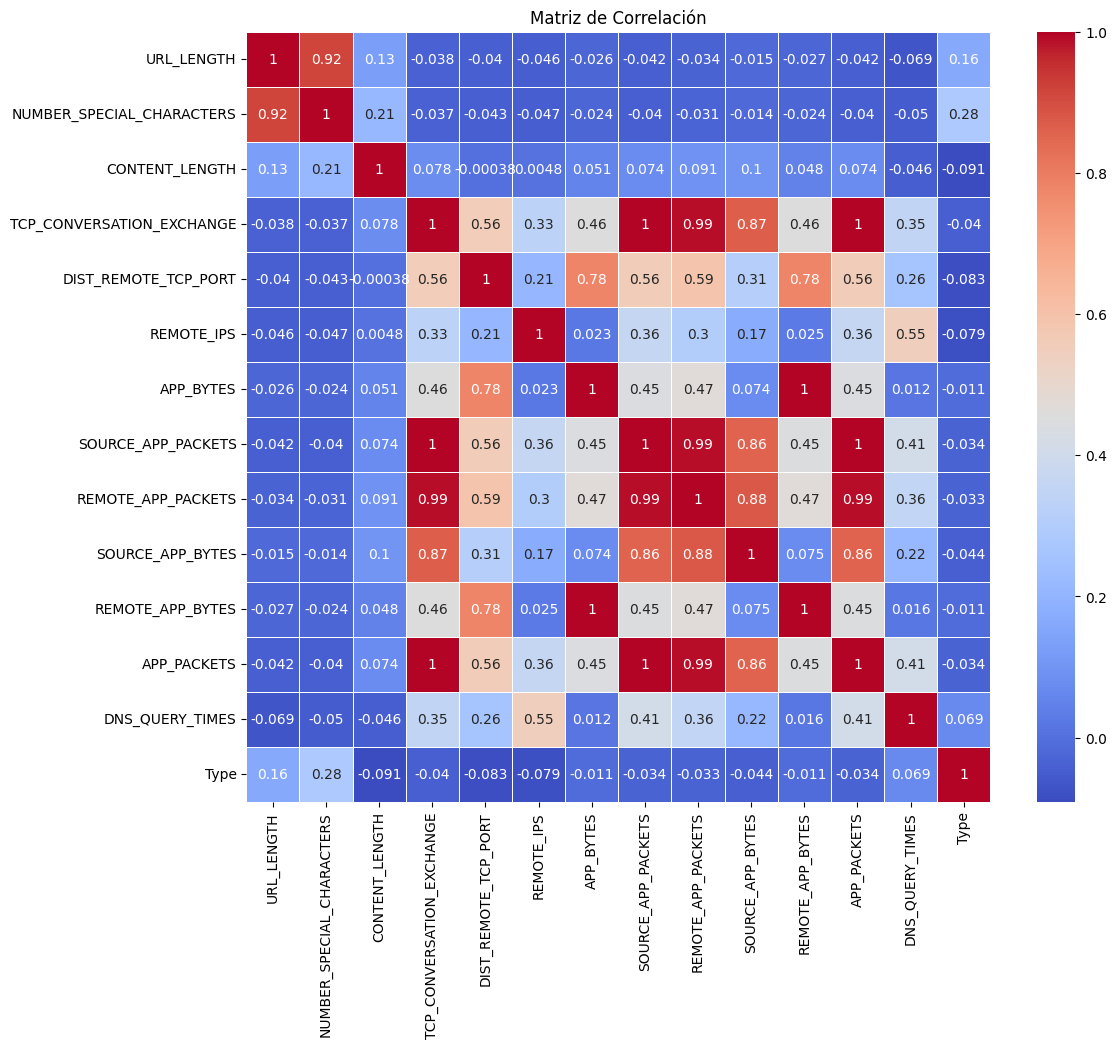

In [146]:
# Seleccionamos variables numericas nada mas 
numeric_columns = websites.select_dtypes(include=[np.number])
# Crear la matriz de correlación
correlation_matrix =numeric_columns.corr()

# Crear el mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()



In [147]:
# Podemos ver que varibles esta extremamente correlacionadas e intuir que podriamos eliminar alguna de esas varibles a nuestra conveniencia 

# Challenge 2 - Remove Column Collinearity.

From the heatmap you created, you should have seen at least 3 columns that can be removed due to high collinearity. Remove these columns from the dataset.

Note that you should remove as few columns as you can. You don't have to remove all the columns at once. But instead, try removing one column, then produce the heatmap again to determine if additional columns should be removed. As long as the dataset no longer contains columns that are correlated for over 90%, you can stop. Also, keep in mind when two columns have high collinearity, you only need to remove one of them but not both.

In the cells below, remove as few columns as you can to eliminate the high collinearity in the dataset. Make sure to comment on your way so that the instructional team can learn about your thinking process which allows them to give feedback. At the end, print the heatmap again.

In [148]:
# Your code here
websites_2 = websites.drop(columns=['TCP_CONVERSATION_EXCHANGE'])
websites_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL                        1781 non-null   object 
 1   URL_LENGTH                 1781 non-null   int64  
 2   NUMBER_SPECIAL_CHARACTERS  1781 non-null   int64  
 3   CHARSET                    1774 non-null   object 
 4   SERVER                     1605 non-null   object 
 5   CONTENT_LENGTH             969 non-null    float64
 6   WHOIS_COUNTRY              1475 non-null   object 
 7   WHOIS_STATEPRO             1419 non-null   object 
 8   WHOIS_REGDATE              1654 non-null   object 
 9   WHOIS_UPDATED_DATE         1642 non-null   object 
 10  DIST_REMOTE_TCP_PORT       1781 non-null   int64  
 11  REMOTE_IPS                 1781 non-null   int64  
 12  APP_BYTES                  1781 non-null   int64  
 13  SOURCE_APP_PACKETS         1781 non-null   int64

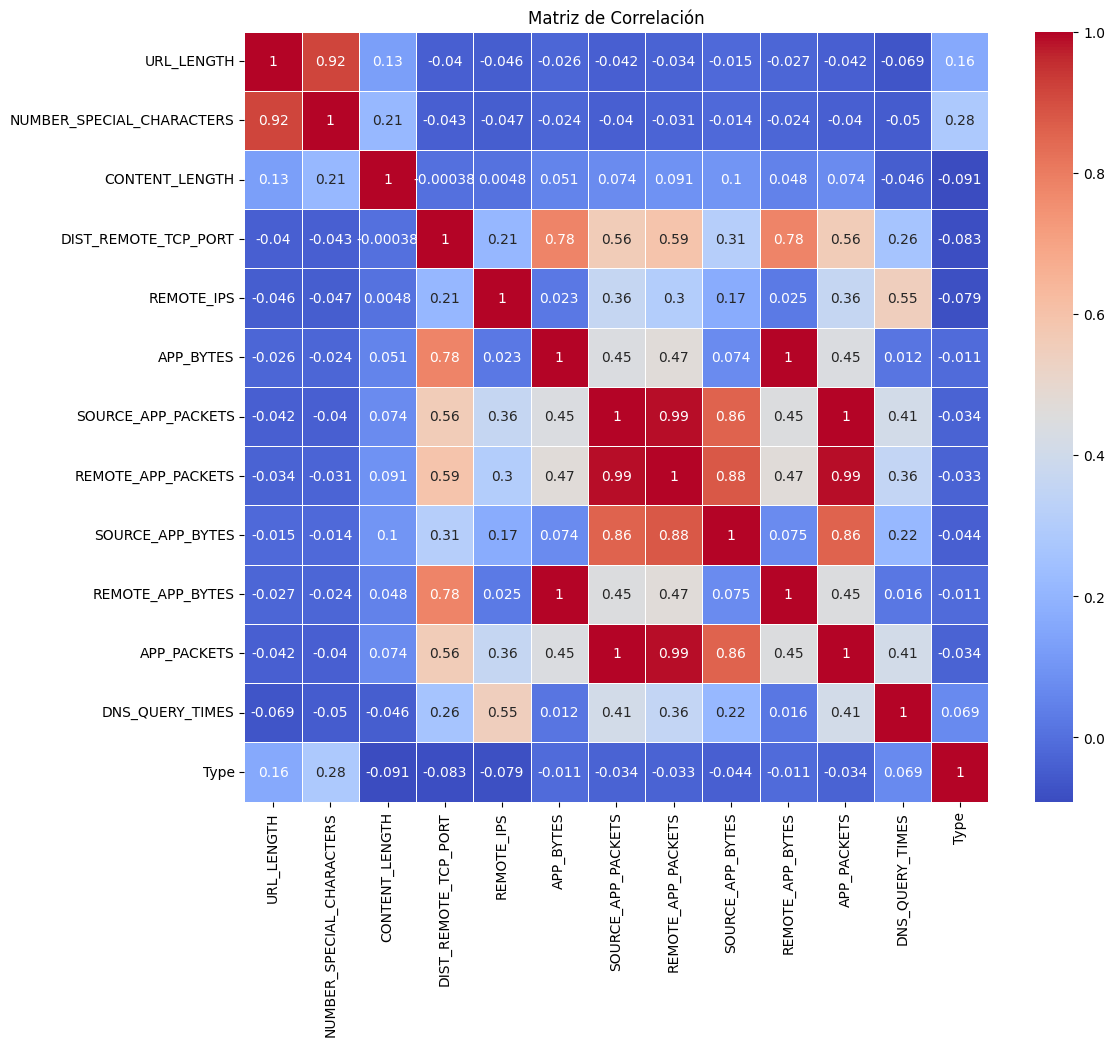

In [149]:
# Seleccionamos variables numericas nada mas 
numeric_columns = websites_2.select_dtypes(include=[np.number])
# Crear la matriz de correlación
correlation_matrix =numeric_columns.corr()

# Crear el mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()


In [150]:
websites_2 = websites_2.drop(columns=["SOURCE_APP_PACKETS"])
websites_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL                        1781 non-null   object 
 1   URL_LENGTH                 1781 non-null   int64  
 2   NUMBER_SPECIAL_CHARACTERS  1781 non-null   int64  
 3   CHARSET                    1774 non-null   object 
 4   SERVER                     1605 non-null   object 
 5   CONTENT_LENGTH             969 non-null    float64
 6   WHOIS_COUNTRY              1475 non-null   object 
 7   WHOIS_STATEPRO             1419 non-null   object 
 8   WHOIS_REGDATE              1654 non-null   object 
 9   WHOIS_UPDATED_DATE         1642 non-null   object 
 10  DIST_REMOTE_TCP_PORT       1781 non-null   int64  
 11  REMOTE_IPS                 1781 non-null   int64  
 12  APP_BYTES                  1781 non-null   int64  
 13  REMOTE_APP_PACKETS         1781 non-null   int64

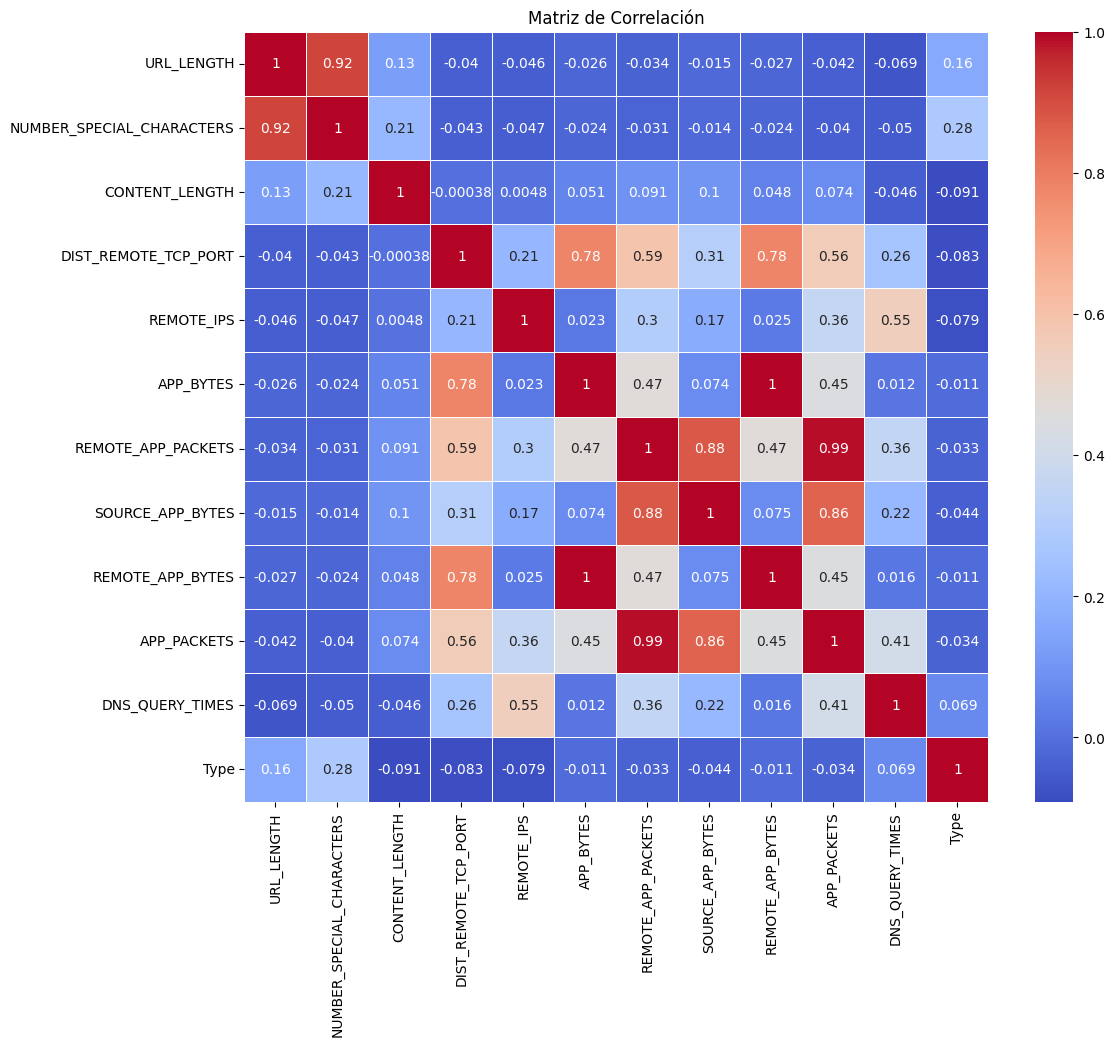

In [151]:
# Seleccionamos variables numericas nada mas 
numeric_columns = websites_2.select_dtypes(include=[np.number])
# Crear la matriz de correlación
correlation_matrix =numeric_columns.corr()

# Crear el mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()


In [152]:
#podemos ver como se siguen relacionado ya con dicha columna eliminada asi poder ver que otra columnas se podrian eliminar sin llegar a 
# afectar ni comprometer el data set 

In [153]:
websites_3 = websites_2.drop(columns=["REMOTE_APP_BYTES","REMOTE_APP_PACKETS"])
websites_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL                        1781 non-null   object 
 1   URL_LENGTH                 1781 non-null   int64  
 2   NUMBER_SPECIAL_CHARACTERS  1781 non-null   int64  
 3   CHARSET                    1774 non-null   object 
 4   SERVER                     1605 non-null   object 
 5   CONTENT_LENGTH             969 non-null    float64
 6   WHOIS_COUNTRY              1475 non-null   object 
 7   WHOIS_STATEPRO             1419 non-null   object 
 8   WHOIS_REGDATE              1654 non-null   object 
 9   WHOIS_UPDATED_DATE         1642 non-null   object 
 10  DIST_REMOTE_TCP_PORT       1781 non-null   int64  
 11  REMOTE_IPS                 1781 non-null   int64  
 12  APP_BYTES                  1781 non-null   int64  
 13  SOURCE_APP_BYTES           1781 non-null   int64

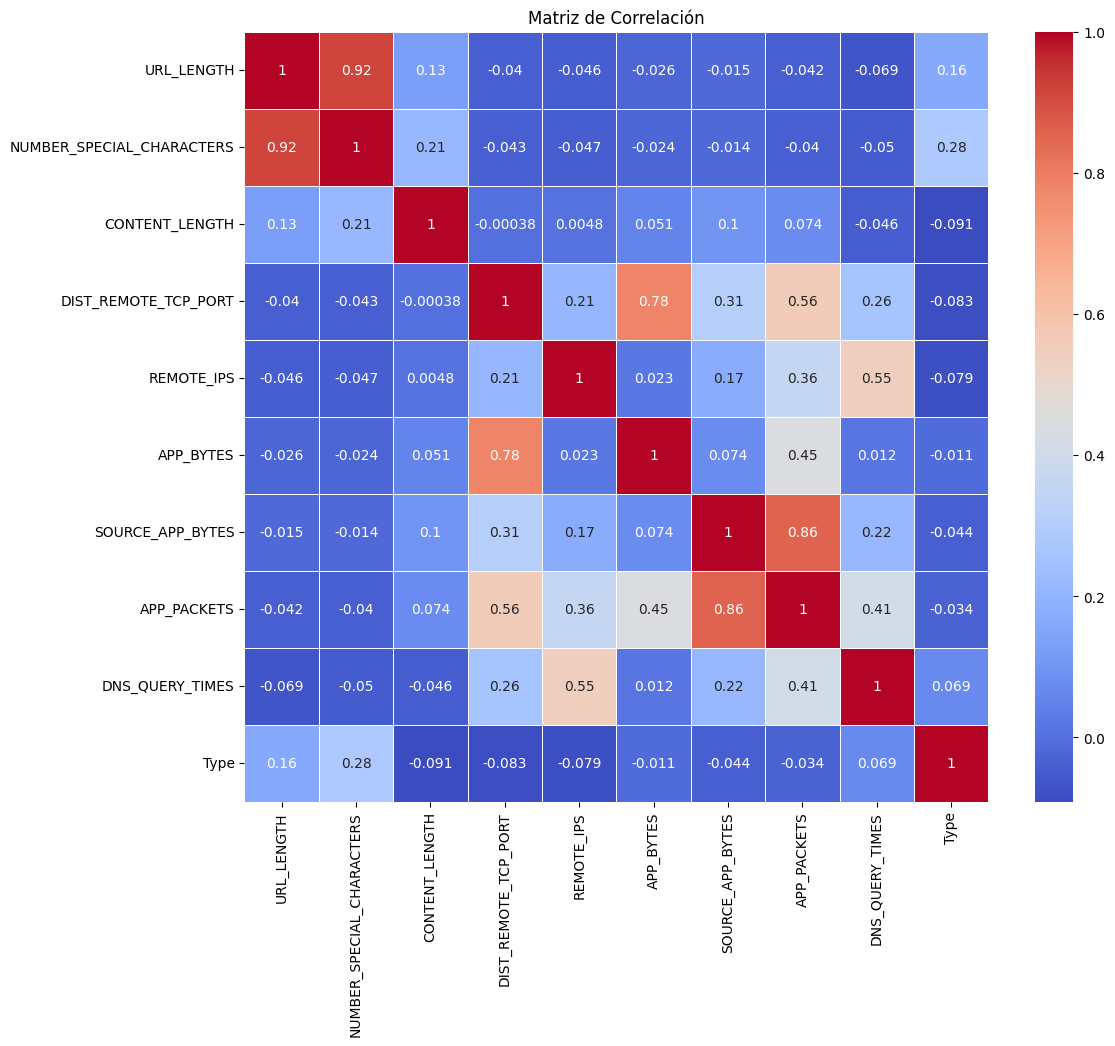

In [154]:
# # Seleccionamos variables numericas nada mas 
numeric_columns = websites_3.select_dtypes(include=[np.number])
# Crear la matriz de correlación
correlation_matrix =numeric_columns.corr()

# Crear el mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()


In [155]:
#ahora vemos que todas las variables que quedan no estan directamente relacionadas 

# Challenge 3 - Handle Missing Values

The next step would be handling missing values. **We start by examining the number of missing values in each column, which you will do in the next cell.**

In [156]:
# Verificar valores nulos en cada columna
valores_nulos = websites_3.isnull().sum()
valores_nulos



URL                            0
URL_LENGTH                     0
NUMBER_SPECIAL_CHARACTERS      0
CHARSET                        7
SERVER                       176
CONTENT_LENGTH               812
WHOIS_COUNTRY                306
WHOIS_STATEPRO               362
WHOIS_REGDATE                127
WHOIS_UPDATED_DATE           139
DIST_REMOTE_TCP_PORT           0
REMOTE_IPS                     0
APP_BYTES                      0
SOURCE_APP_BYTES               0
APP_PACKETS                    0
DNS_QUERY_TIMES                1
Type                           0
dtype: int64

In [157]:
# Verificar el porcentaje de valores nulos en cada columna
porcentaje_nulos = websites_3.isnull().mean() * 100
porcentaje_nulos


URL                           0.000000
URL_LENGTH                    0.000000
NUMBER_SPECIAL_CHARACTERS     0.000000
CHARSET                       0.393038
SERVER                        9.882089
CONTENT_LENGTH               45.592364
WHOIS_COUNTRY                17.181359
WHOIS_STATEPRO               20.325660
WHOIS_REGDATE                 7.130825
WHOIS_UPDATED_DATE            7.804604
DIST_REMOTE_TCP_PORT          0.000000
REMOTE_IPS                    0.000000
APP_BYTES                     0.000000
SOURCE_APP_BYTES              0.000000
APP_PACKETS                   0.000000
DNS_QUERY_TIMES               0.056148
Type                          0.000000
dtype: float64

If you remember in the previous labs, we drop a column if the column contains a high proportion of missing values. After dropping those problematic columns, we drop the rows with missing values.

#### In the cells below, handle the missing values from the dataset. Remember to comment the rationale of your decisions.

In [158]:
websites_3=websites_3.drop(columns=["CONTENT_LENGTH"])


In [159]:
websites_3

,URL,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CHARSET,SERVER,WHOIS_COUNTRY,WHOIS_STATEPRO,WHOIS_REGDATE,WHOIS_UPDATED_DATE,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
0,M0_109,16,7,iso-8859-1,nginx,NaN,NaN,10/10/2015 18:21,NaN,0,2,700,1153,9,2.0,1
1,B0_2314,16,6,UTF-8,Apache/2.4.10,NaN,NaN,NaN,NaN,7,4,1230,1265,17,0.0,0
2,B0_911,16,6,us-ascii,Microsoft-HTTPAPI/2.0,NaN,NaN,NaN,NaN,0,0,0,0,0,0.0,0
3,B0_113,17,6,ISO-8859-1,nginx,US,AK,7/10/1997 4:00,12/09/2013 0:45,22,3,3812,18784,39,8.0,0
4,B0_403,17,6,UTF-8,NaN,US,TX,12/05/1996 0:00,11/04/2017 0:00,2,5,4278,129889,61,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,M4_48,194,16,UTF-8,Apache,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,0,0,0,186,0,0.0,1
1777,M4_41,198,17,UTF-8,Apache,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,0,0,0,124,0,0.0,1
1778,B0_162,201,34,utf-8,Apache/2.2.16 (Debian),US,FL,15/02/1999 0:00,15/07/2015 0:00,2,6,6631,132181,87,4.0,0
1779,B0_1152,234,34,ISO-8859-1,cloudflare-nginx,US,CA,1/04/1998 0:00,9/12/2016 0:00,0,0,0,0,0,0.0,0


In [160]:
# Sustituir valores nulos en las columnas 'WHOIS_COUNTRY' y 'WHOIS_STATEPRO' por 'Unknown'
websites_3['WHOIS_COUNTRY'] = websites_3['WHOIS_COUNTRY'].fillna('Unknown')
websites_3['WHOIS_STATEPRO'] = websites_3['WHOIS_STATEPRO'].fillna('Unknown')

# Verificar que los valores nulos han sido sustituidos
websites_3[['WHOIS_COUNTRY', 'WHOIS_STATEPRO']].isnull().sum()


WHOIS_COUNTRY     0
WHOIS_STATEPRO    0
dtype: int64

In [163]:
from datetime import datetime

# Obtener la fecha de hoy
fecha_hoy = datetime.now()

# Rellenar los valores nulos con la fecha de hoy
websites_3['WHOIS_REGDATE'] = websites['WHOIS_REGDATE'].fillna(fecha_hoy)
websites_3['WHOIS_UPDATED_DATE'] = websites['WHOIS_UPDATED_DATE'].fillna(fecha_hoy)



In [171]:
# Sustituir valores nulos en la columna 'SERVER' por 'Unknown'
websites_3['SERVER'] = websites['SERVER'].fillna('Unknown')


In [183]:
# Eliminar filas con valores nulos en las columnas 'CHARSET' y 'DNS_QUERY_TIMES'
websites_3 = websites_3.dropna(subset=['CHARSET', 'DNS_QUERY_TIMES'])



In [180]:
 websites_3

,URL,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CHARSET,SERVER,WHOIS_COUNTRY,WHOIS_STATEPRO,WHOIS_REGDATE,WHOIS_UPDATED_DATE,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
0,M0_109,16,7,iso-8859-1,nginx,Unknown,Unknown,10/10/2015 18:21,2025-01-31 17:57:17.806320,0,2,700,1153,9,2.0,1
1,B0_2314,16,6,UTF-8,Apache/2.4.10,Unknown,Unknown,2025-01-31 17:57:17.806320,2025-01-31 17:57:17.806320,7,4,1230,1265,17,0.0,0
2,B0_911,16,6,us-ascii,Microsoft-HTTPAPI/2.0,Unknown,Unknown,2025-01-31 17:57:17.806320,2025-01-31 17:57:17.806320,0,0,0,0,0,0.0,0
3,B0_113,17,6,ISO-8859-1,nginx,US,AK,7/10/1997 4:00,12/09/2013 0:45,22,3,3812,18784,39,8.0,0
4,B0_403,17,6,UTF-8,Unknown,US,TX,12/05/1996 0:00,11/04/2017 0:00,2,5,4278,129889,61,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,M4_48,194,16,UTF-8,Apache,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,0,0,0,186,0,0.0,1
1777,M4_41,198,17,UTF-8,Apache,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,0,0,0,124,0,0.0,1
1778,B0_162,201,34,utf-8,Apache/2.2.16 (Debian),US,FL,15/02/1999 0:00,15/07/2015 0:00,2,6,6631,132181,87,4.0,0
1779,B0_1152,234,34,ISO-8859-1,cloudflare-nginx,US,CA,1/04/1998 0:00,9/12/2016 0:00,0,0,0,0,0,0.0,0


In [ ]:
#COLUMNAS CON VALORES NULOS RELLENADOS:
#WHOIS_COUNTRY y WHOIS_STATEPRO: Rellenamos los valores nulos con la categoría "Unknown".
#SERVER: Rellenamos los valores nulos con la categoría "Unknown".
#WHOIS_REGDATE y WHOIS_UPDATED_DATE: Rellenamos los valores nulos con la fecha actual.
#COLUMNAS CON FILAS ELIMINADAS:
#CHARSET y DNS_QUERY_TIMES: Eliminamos las filas que contenían valores nulos en estas columnas.
# Tenemos encuenta que se intentamos perder las menos informacion posible no significa que no podamos volver y cambiar alguno de estos pasos 

#### Again, examine the number of missing values in each column. 

If all cleaned, proceed. Otherwise, go back and do more cleaning.

In [13]:
# Examine missing values in each column


In [184]:
 websites_3.isnull().sum()

URL                          0
URL_LENGTH                   0
NUMBER_SPECIAL_CHARACTERS    0
CHARSET                      0
SERVER                       0
WHOIS_COUNTRY                0
WHOIS_STATEPRO               0
WHOIS_REGDATE                0
WHOIS_UPDATED_DATE           0
DIST_REMOTE_TCP_PORT         0
REMOTE_IPS                   0
APP_BYTES                    0
SOURCE_APP_BYTES             0
APP_PACKETS                  0
DNS_QUERY_TIMES              0
Type                         0
dtype: int64

# Challenge 4 - Handle `WHOIS_*` Categorical Data

There are several categorical columns we need to handle. These columns are:

* `URL`
* `CHARSET`
* `SERVER`
* `WHOIS_COUNTRY`
* `WHOIS_STATEPRO`
* `WHOIS_REGDATE`
* `WHOIS_UPDATED_DATE`

How to handle string columns is always case by case. Let's start by working on `WHOIS_COUNTRY`. Your steps are:

1. List out the unique values of `WHOIS_COUNTRY`.
1. Consolidate the country values with consistent country codes. For example, the following values refer to the same country and should use consistent country code:
    * `CY` and `Cyprus`
    * `US` and `us`
    * `SE` and `se`
    * `GB`, `United Kingdom`, and `[u'GB'; u'UK']`

#### In the cells below, fix the country values as intructed above.

In [186]:
unique_countries = websites_3['WHOIS_COUNTRY'].unique()
unique_countries



array(['Unknown', 'US', 'SC', 'GB', 'UK', 'RU', 'AU', 'CA', 'PA', 'se',
       'IN', 'LU', 'TH', "[u'GB'; u'UK']", 'FR', 'NL', 'UG', 'JP', 'CN',
       'SE', 'SI', 'IL', 'ru', 'KY', 'AT', 'CZ', 'PH', 'BE', 'NO', 'TR',
       'LV', 'DE', 'ES', 'BR', 'us', 'KR', 'HK', 'UA', 'CH',
       'United Kingdom', 'BS', 'PK', 'IT', 'Cyprus', 'BY', 'AE', 'IE',
       'UY', 'KG'], dtype=object)

In [189]:
# Crear un diccionario para mapear los valores inconsistentes a códigos de país consistentes
country_mapping = {
    'Cyprus': 'CY',
    'us': 'US',
    'se': 'SE',
    'United Kingdom': 'GB',
    "[u'GB'; u'UK']": 'GB'}
# Aplicar el mapeo a la columna WHOIS_COUNTRY usando .loc
websites_3.loc[:, 'WHOIS_COUNTRY'] = websites_3['WHOIS_COUNTRY'].replace(country_mapping)



In [191]:
#Verificamos
unique_countries_after = websites_3['WHOIS_COUNTRY'].unique()
unique_countries_after

array(['Unknown', 'US', 'SC', 'GB', 'UK', 'RU', 'AU', 'CA', 'PA', 'SE',
       'IN', 'LU', 'TH', 'FR', 'NL', 'UG', 'JP', 'CN', 'SI', 'IL', 'ru',
       'KY', 'AT', 'CZ', 'PH', 'BE', 'NO', 'TR', 'LV', 'DE', 'ES', 'BR',
       'KR', 'HK', 'UA', 'CH', 'BS', 'PK', 'IT', 'CY', 'BY', 'AE', 'IE',
       'UY', 'KG'], dtype=object)

Since we have fixed the country values, can we convert this column to ordinal now?

Not yet. If you reflect on the previous labs how we handle categorical columns, you probably remember we ended up dropping a lot of those columns because there are too many unique values. Too many unique values in a column is not desirable in machine learning because it makes prediction inaccurate. But there are workarounds under certain conditions. One of the fixable conditions is:

#### If a limited number of values account for the majority of data, we can retain these top values and re-label all other rare values.

The `WHOIS_COUNTRY` column happens to be this case. You can verify it by print a bar chart of the `value_counts` in the next cell to verify:

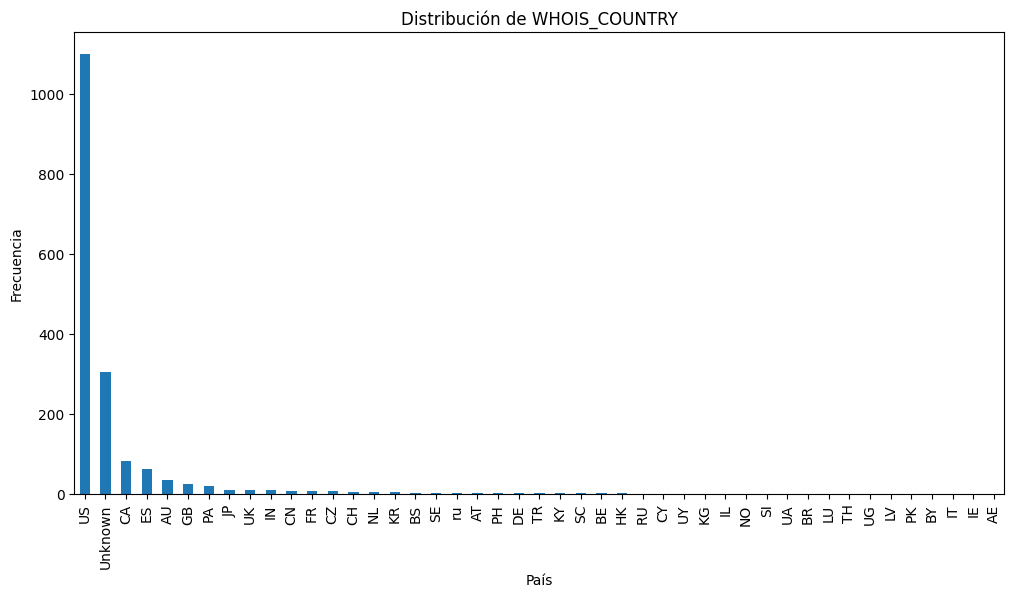

In [193]:
# Contar los valores únicos en la columna WHOIS_COUNTRY
country_counts = websites_3['WHOIS_COUNTRY'].value_counts()

# Crear un gráfico de barras
plt.figure(figsize=(12, 6))
country_counts.plot(kind='bar')
plt.title('Distribución de WHOIS_COUNTRY')
plt.xlabel('País')
plt.ylabel('Frecuencia')
plt.show()



#### After verifying, now let's keep the top 10 values of the column and re-label other columns with `OTHER`.

In [194]:
#Obtener los 10 valores más frecuentes:
top_10_countries = websites_3['WHOIS_COUNTRY'].value_counts().nlargest(10).index



In [196]:
#Re-etiquetar los valores menos frecuentes como "OTHER":
websites_3.loc[:, 'WHOIS_COUNTRY'] = websites_3['WHOIS_COUNTRY'].apply(lambda x: x if x in top_10_countries else 'OTHER')



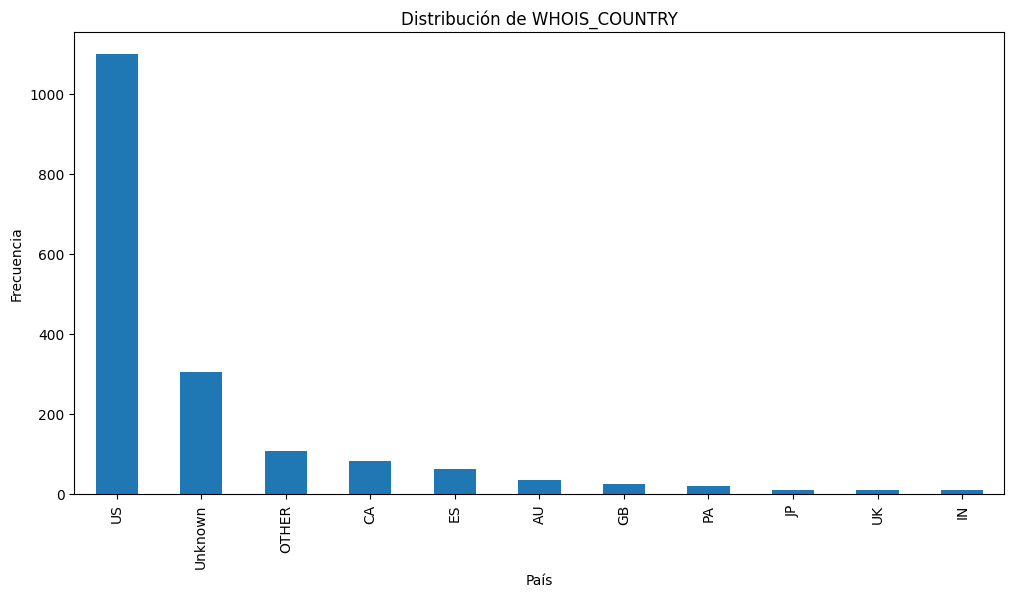

In [197]:
#VERIFICAMOS
# Contar los valores únicos en la columna WHOIS_COUNTRY
country_counts2 = websites_3['WHOIS_COUNTRY'].value_counts()

# Crear un gráfico de barras
plt.figure(figsize=(12, 6))
country_counts2.plot(kind='bar')
plt.title('Distribución de WHOIS_COUNTRY')
plt.xlabel('País')
plt.ylabel('Frecuencia')
plt.show()

Now since `WHOIS_COUNTRY` has been re-labelled, we don't need `WHOIS_STATEPRO` any more because the values of the states or provinces may not be relevant any more. We'll drop this column.

In addition, we will also drop `WHOIS_REGDATE` and `WHOIS_UPDATED_DATE`. These are the registration and update dates of the website domains. Not of our concerns.

#### In the next cell, drop `['WHOIS_STATEPRO', 'WHOIS_REGDATE', 'WHOIS_UPDATED_DATE']`.

In [201]:
# Eliminar las columnas 'WHOIS_STATEPRO', 'WHOIS_REGDATE' y 'WHOIS_UPDATED_DATE'
websites_3 = websites_3.drop(columns=['WHOIS_STATEPRO', 'WHOIS_REGDATE', 'WHOIS_UPDATED_DATE'])



KeyError: "['WHOIS_STATEPRO', 'WHOIS_REGDATE', 'WHOIS_UPDATED_DATE'] not found in axis"

# Challenge 5 - Handle Remaining Categorical Data & Convert to Ordinal

Now print the `dtypes` of the data again. Besides `WHOIS_COUNTRY` which we already fixed, there should be 3 categorical columns left: `URL`, `CHARSET`, and `SERVER`.

In [202]:
# Verificar que las columnas han sido eliminadas
websites_3.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1773 entries, 0 to 1780
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL                        1773 non-null   object 
 1   URL_LENGTH                 1773 non-null   int64  
 2   NUMBER_SPECIAL_CHARACTERS  1773 non-null   int64  
 3   CHARSET                    1773 non-null   object 
 4   SERVER                     1773 non-null   object 
 5   WHOIS_COUNTRY              1773 non-null   object 
 6   DIST_REMOTE_TCP_PORT       1773 non-null   int64  
 7   REMOTE_IPS                 1773 non-null   int64  
 8   APP_BYTES                  1773 non-null   int64  
 9   SOURCE_APP_BYTES           1773 non-null   int64  
 10  APP_PACKETS                1773 non-null   int64  
 11  DNS_QUERY_TIMES            1773 non-null   float64
 12  Type                       1773 non-null   int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 193.

#### `URL` is easy. We'll simply drop it because it has too many unique values that there's no way for us to consolidate.

In [203]:
# Eliminar la columna 'URL'
websites_3 = websites_3.drop(columns=['URL'])

# Verificar que la columna ha sido eliminada
websites_3.columns



Index(['URL_LENGTH', 'NUMBER_SPECIAL_CHARACTERS', 'CHARSET', 'SERVER',
       'WHOIS_COUNTRY', 'DIST_REMOTE_TCP_PORT', 'REMOTE_IPS', 'APP_BYTES',
       'SOURCE_APP_BYTES', 'APP_PACKETS', 'DNS_QUERY_TIMES', 'Type'],
      dtype='object')

#### Print the unique value counts of `CHARSET`. You see there are only a few unique values. So we can keep it as it is.

In [204]:
# Imprimir los valores únicos y sus conteos en la columna 'CHARSET'
charset_counts = websites_3['CHARSET'].value_counts()
print(charset_counts)


CHARSET
UTF-8           675
ISO-8859-1      427
utf-8           379
us-ascii        155
iso-8859-1      134
windows-1251      1
ISO-8859          1
windows-1252      1
Name: count, dtype: int64


`SERVER` is a little more complicated. Print its unique values and think about how you can consolidate those values.

#### Before you think of your own solution, don't read the instructions that come next.

In [205]:
# Imprimir los valores únicos y sus conteos en la columna 'SERVER'
server_counts = websites_3['SERVER'].value_counts()
print(server_counts)



SERVER
Apache                                                           385
nginx                                                            211
Unknown                                                          175
Microsoft-HTTPAPI/2.0                                            113
cloudflare-nginx                                                  94
                                                                ... 
My Arse                                                            1
IdeaWebServer/v0.80                                                1
Apache/2.4.17 (Unix) OpenSSL/1.0.1e-fips PHP/5.6.19                1
Microsoft-IIS/7.5; litigation_essentials.lexisnexis.com  9999      1
Apache/2.2.16 (Debian)                                             1
Name: count, Length: 237, dtype: int64


![Think Hard](../images/think-hard.jpg)

In [24]:
# Your comment here
#podemos observar que los tipos de servidores son muy diferentes pero contienen partes iguales 

Although there are so many unique values in the `SERVER` column, there are actually only 3 main server types: `Microsoft`, `Apache`, and `nginx`. Just check if each `SERVER` value contains any of those server types and re-label them. For `SERVER` values that don't contain any of those substrings, label with `Other`.

At the end, your `SERVER` column should only contain 4 unique values: `Microsoft`, `Apache`, `nginx`, and `Other`.

In [206]:
# Función para re-etiquetar los valores de la columna SERVER
def categorize_server(server):
    if 'Microsoft' in server:
        return 'Microsoft'
    elif 'Apache' in server:
        return 'Apache'
    elif 'nginx' in server:
        return 'nginx'
    else:
        return 'Other'

# Aplicar la función a la columna SERVER
websites_3['SERVER'] = websites_3['SERVER'].apply(categorize_server)



In [207]:
# Verificar los valores únicos después de la re-etiquetación
unique_servers_after = websites_3['SERVER'].unique()
print(unique_servers_after)



['nginx' 'Apache' 'Microsoft' 'Other']


OK, all our categorical data are fixed now. **Let's convert them to ordinal data using Pandas' `get_dummies` function ([documentation](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html)).** Make sure you drop the categorical columns by passing `drop_first=True` to `get_dummies` as we don't need them any more. **Also, assign the data with dummy values to a new variable `website_dummy`.**

In [208]:
# Convertir las columnas categóricas a datos ordinales usando get_dummies
website_dummy = pd.get_dummies(websites_3, drop_first=True)




Now, inspect `website_dummy` to make sure the data and types are intended - there shouldn't be any categorical columns at this point.

In [210]:
# Verificar las columnas del nuevo DataFrame
website_dummy.info()



<class 'pandas.core.frame.DataFrame'>
Index: 1773 entries, 0 to 1780
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL_LENGTH                 1773 non-null   int64  
 1   NUMBER_SPECIAL_CHARACTERS  1773 non-null   int64  
 2   DIST_REMOTE_TCP_PORT       1773 non-null   int64  
 3   REMOTE_IPS                 1773 non-null   int64  
 4   APP_BYTES                  1773 non-null   int64  
 5   SOURCE_APP_BYTES           1773 non-null   int64  
 6   APP_PACKETS                1773 non-null   int64  
 7   DNS_QUERY_TIMES            1773 non-null   float64
 8   Type                       1773 non-null   int64  
 9   CHARSET_ISO-8859-1         1773 non-null   bool   
 10  CHARSET_UTF-8              1773 non-null   bool   
 11  CHARSET_iso-8859-1         1773 non-null   bool   
 12  CHARSET_us-ascii           1773 non-null   bool   
 13  CHARSET_utf-8              1773 non-null   bool   
 1

In [213]:
# Convertir los valores booleanos a enteros (0 o 1)
website_dummy = website_dummy.astype(int)

In [214]:
website_dummy

,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type,CHARSET_ISO-8859-1,...,WHOIS_COUNTRY_CA,WHOIS_COUNTRY_ES,WHOIS_COUNTRY_GB,WHOIS_COUNTRY_IN,WHOIS_COUNTRY_JP,WHOIS_COUNTRY_OTHER,WHOIS_COUNTRY_PA,WHOIS_COUNTRY_UK,WHOIS_COUNTRY_US,WHOIS_COUNTRY_Unknown
0,16,7,0,2,700,1153,9,2,1,0,...,0,0,0,0,0,0,0,0,0,1
1,16,6,7,4,1230,1265,17,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,16,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,17,6,22,3,3812,18784,39,8,0,1,...,0,0,0,0,0,0,0,0,1,0
4,17,6,2,5,4278,129889,61,4,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,194,16,0,0,0,186,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
1777,198,17,0,0,0,124,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
1778,201,34,2,6,6631,132181,87,4,0,0,...,0,0,0,0,0,0,0,0,1,0
1779,234,34,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


In [215]:
# Verificar las columnas del nuevo DataFrame
website_dummy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1773 entries, 0 to 1780
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   URL_LENGTH                 1773 non-null   int64
 1   NUMBER_SPECIAL_CHARACTERS  1773 non-null   int64
 2   DIST_REMOTE_TCP_PORT       1773 non-null   int64
 3   REMOTE_IPS                 1773 non-null   int64
 4   APP_BYTES                  1773 non-null   int64
 5   SOURCE_APP_BYTES           1773 non-null   int64
 6   APP_PACKETS                1773 non-null   int64
 7   DNS_QUERY_TIMES            1773 non-null   int64
 8   Type                       1773 non-null   int64
 9   CHARSET_ISO-8859-1         1773 non-null   int64
 10  CHARSET_UTF-8              1773 non-null   int64
 11  CHARSET_iso-8859-1         1773 non-null   int64
 12  CHARSET_us-ascii           1773 non-null   int64
 13  CHARSET_utf-8              1773 non-null   int64
 14  CHARSET_windows-1251       17

# Challenge 6 - Modeling, Prediction, and Evaluation

We'll start off this section by splitting the data to train and test. **Name your 4 variables `X_train`, `X_test`, `y_train`, and `y_test`. Select 80% of the data for training and 20% for testing.**

In [216]:
from sklearn.model_selection import train_test_split

# Definir las características (X) y la variable objetivo (y)
X = website_dummy.drop(columns=['Type'])
y = website_dummy['Type']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar las dimensiones de los conjuntos de datos
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (1418, 28)
X_test shape: (355, 28)
y_train shape: (1418,)
y_test shape: (355,)


#### In this lab, we will try two different models and compare our results.

The first model we will use in this lab is logistic regression. We have previously learned about logistic regression as a classification algorithm. In the cell below, load `LogisticRegression` from scikit-learn and initialize the model.

In [217]:
from sklearn.linear_model import LogisticRegression

# Inicializar el modelo de regresión logística
logistic_model = LogisticRegression()

# Verificar la inicialización del modelo
print(logistic_model)




LogisticRegression()


#Next, fit the model to our training data. We have already separated our data into 4 parts. Use those in your model.

In [223]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)




C:\Users\Jose Luis\.conda\envs\sklearn-env\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

finally, import `confusion_matrix` and `accuracy_score` from `sklearn.metrics` and fit our testing data. Assign the fitted data to `y_pred` and print the confusion matrix as well as the accuracy score

In [224]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Predecir los valores para los datos de prueba
y_pred = logistic_model.predict(X_test)

# Imprimir la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(conf_matrix)

# Imprimir la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del Modelo:")
print(accuracy)




Matriz de Confusión:
[[303  10]
 [ 14  28]]
Precisión del Modelo:
0.9323943661971831


What are your thoughts on the performance of the model? Write your conclusions below.

In [33]:
# Your conclusions here:
#El modelo de regresión logística ha tenido un buen desempeño, logrando una precisión de aproximadamente 93.24%.
#La matriz de confusión indica que el modelo clasificó correctamente 303 sitios web benignos y 28 sitios web maliciosos.
# Sin embargo, clasificó incorrectamente 10 sitios web benignos como maliciosos y 14 sitios web maliciosos como benignos.
#Conclusiones:
#Alta Precisión: La precisión del modelo del 93.24% es impresionante, lo que indica que puede distinguir de manera confiable entre sitios web benignos y maliciosos.
#Falsos Positivos y Negativos: Aunque el número de falsos positivos (10) y falsos negativos (14) es relativamente bajo, estas clasificaciones incorrectas aún podrían ser significativas dependiendo del contexto.
#Por ejemplo, etiquetar incorrectamente un sitio web benigno como malicioso podría llevar a acciones innecesarias,
#mientras que no detectar un sitio web malicioso podría representar riesgos de seguridad

#### Our second algorithm is is K-Nearest Neighbors. 

Though is it not required, we will fit a model using the training data and then test the performance of the model using the testing data. Start by loading `KNeighborsClassifier` from scikit-learn and then initializing and fitting the model. We'll start off with a model where k=3.

In [225]:
from sklearn.neighbors import KNeighborsClassifier

# Inicializar el modelo K-Nearest Neighbors con k=3
knn_model = KNeighborsClassifier(n_neighbors=3)

# Ajustar el modelo a los datos de entrenamiento
knn_model.fit(X_train, y_train)

# Verificar la inicialización y ajuste del modelo
print(knn_model)



KNeighborsClassifier(n_neighbors=3)


To test your model, compute the predicted values for the testing sample and print the confusion matrix as well as the accuracy score.

In [226]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Predecir los valores para los datos de prueba
y_pred = knn_model.predict(X_test)

# Imprimir la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión (k=3):")
print(conf_matrix)

# Imprimir la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del Modelo (k=3):")
print(accuracy)




Matriz de Confusión (k=3):
[[303  10]
 [ 13  29]]
Precisión del Modelo (k=3):
0.9352112676056338


#### We'll create another K-Nearest Neighbors model with k=5. 

Initialize and fit the model below and print the confusion matrix and the accuracy score.

In [227]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Inicializar el modelo K-Nearest Neighbors con k=5
knn_model_k5 = KNeighborsClassifier(n_neighbors=5)

# Ajustar el modelo a los datos de entrenamiento
knn_model_k5.fit(X_train, y_train)

# Predecir los valores para los datos de prueba
y_pred_k5 = knn_model_k5.predict(X_test)

# Imprimir la matriz de confusión
conf_matrix_k5 = confusion_matrix(y_test, y_pred_k5)
print("Matriz de Confusión (k=5):")
print(conf_matrix_k5)

# Imprimir la precisión del modelo
accuracy_k5 = accuracy_score(y_test, y_pred_k5)
print("Precisión del Modelo (k=5):")
print(accuracy_k5)




Matriz de Confusión (k=5):
[[302  11]
 [ 17  25]]
Precisión del Modelo (k=5):
0.9211267605633803


Did you see an improvement in the confusion matrix when increasing k to 5? Did you see an improvement in the accuracy score? Write your conclusions below.

In [37]:
# Your conclusions here:Resumen:
#Al comparar los dos modelos, podemos observar que el modelo con k=3 tiene una mejor precisión (93.52%)
#en comparación con el modelo con k=5 (92.11%). Además, el modelo con k=3 tiene menos falsos negativos (13) y
#falsos positivos (10) en comparación con el modelo con k=5 (17 falsos negativos y 11 falsos positivos).

#En general, el modelo con k=3 parece ser más efectivo para clasificar correctamente los sitios web benignos
#y maliciosos



# Bonus Challenge - Feature Scaling

Problem-solving in machine learning is iterative. You can improve your model prediction with various techniques (there is a sweetspot for the time you spend and the improvement you receive though). Now you've completed only one iteration of ML analysis. There are more iterations you can conduct to make improvements. In order to be able to do that, you will need deeper knowledge in statistics and master more data analysis techniques. In this bootcamp, we don't have time to achieve that advanced goal. But you will make constant efforts after the bootcamp to eventually get there.

However, now we do want you to learn one of the advanced techniques which is called *feature scaling*. The idea of feature scaling is to standardize/normalize the range of independent variables or features of the data. This can make the outliers more apparent so that you can remove them. This step needs to happen during Challenge 6 after you split the training and test data because you don't want to split the data again which makes it impossible to compare your results with and without feature scaling. For general concepts about feature scaling, click [here](https://en.wikipedia.org/wiki/Feature_scaling). To read deeper, click [here](https://medium.com/greyatom/why-how-and-when-to-scale-your-features-4b30ab09db5e).

In the next cell, attempt to improve your model prediction accuracy by means of feature scaling. A library you can utilize is `sklearn.preprocessing.RobustScaler` ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html)). You'll use the `RobustScaler` to fit and transform your `X_train`, then transform `X_test`. You will use logistic regression to fit and predict your transformed data and obtain the accuracy score in the same way. Compare the accuracy score with your normalized data with the previous accuracy data. Is there an improvement?

In [228]:
#Escalar las características: Utiliza sklearn.preprocessing.RobustScaler para ajustar y transformar tu X_train, luego transforma X_test.
from sklearn.preprocessing import RobustScaler

# Inicializar el escalador
scaler = RobustScaler()

# Ajustar y transformar X_train
X_train_scaled = scaler.fit_transform(X_train)

# Transformar X_test
X_test_scaled = scaler.transform(X_test)


In [230]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Inicializar el modelo de regresión logística
logistic_model = LogisticRegression()

# Ajustar el modelo a los datos escalados
logistic_model.fit(X_train_scaled, y_train)

# Predecir los valores para los datos de prueba escalados
y_pred_scaled = logistic_model.predict(X_test_scaled)

# Obtener el puntaje de precisión
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
print("Precisión del Modelo con Escalado de Características:")
print(accuracy_scaled)


Precisión del Modelo con Escalado de Características:
0.9323943661971831


In [233]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Inicializar el modelo K-Nearest Neighbors con k=3
knn_model_k3 = KNeighborsClassifier(n_neighbors=3)

# Ajustar el modelo a los datos escalados
knn_model_k3.fit(X_train_scaled, y_train)

# Predecir los valores para los datos de prueba escalados
y_pred_k3_scaled = knn_model_k3.predict(X_test_scaled)

# Imprimir la matriz de confusión
conf_matrix_k3_scaled = confusion_matrix(y_test, y_pred_k3_scaled)
print("Matriz de Confusión (k=3) con Escalado de Características:")
print(conf_matrix_k3_scaled)

# Imprimir la precisión del modelo
accuracy_k3_scaled = accuracy_score(y_test, y_pred_k3_scaled)
print("Precisión del Modelo (k=3) con Escalado de Características:")
print(accuracy_k3_scaled)


Matriz de Confusión (k=3) con Escalado de Características:
[[306   7]
 [ 12  30]]
Precisión del Modelo (k=3) con Escalado de Características:
0.9464788732394366


In [234]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Inicializar el modelo K-Nearest Neighbors con k=5
knn_model_k5 = KNeighborsClassifier(n_neighbors=5)

# Ajustar el modelo a los datos escalados
knn_model_k5.fit(X_train_scaled, y_train)

# Predecir los valores para los datos de prueba escalados
y_pred_k5_scaled = knn_model_k5.predict(X_test_scaled)

# Imprimir la matriz de confusión
conf_matrix_k5_scaled = confusion_matrix(y_test, y_pred_k5_scaled)
print("Matriz de Confusión (k=5) con Escalado de Características:")
print(conf_matrix_k5_scaled)

# Imprimir la precisión del modelo
accuracy_k5_scaled = accuracy_score(y_test, y_pred_k5_scaled)
print("Precisión del Modelo (k=5) con Escalado de Características:")
print(accuracy_k5_scaled)


Matriz de Confusión (k=5) con Escalado de Características:
[[306   7]
 [ 12  30]]
Precisión del Modelo (k=5) con Escalado de Características:
0.9464788732394366


In [231]:
#Conclusiones:
#Regresión Logística: Este modelo tiene una precisión del 93.52%. Aunque es bastante alta, es ligeramente inferior a los modelos K-Nearest Neighbors con k=3 y k=5.
#K-Nearest Neighbors (k=3): Este modelo tiene una precisión del 94.65%, lo que es una mejora significativa en comparación con la regresión logística. Además, tiene menos falsos positivos y falsos negativos.
#K-Nearest Neighbors (k=5): Este modelo también tiene una precisión del 94.65%, similar al modelo con k=3. La matriz de confusión es idéntica a la del modelo con k=3.
#PODEMOS CONCLUIR QUE EL MODELO K3 ES EL MAS EFECTIVO PARA ESTE CASO DE USO 

array([[ 1.6       ,  2.25      ,  0.2       , ...,  0.        ,
         0.        ,  0.        ],
       [-0.10434783,  0.        ,  5.2       , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.49565217,  2.        ,  2.        , ...,  0.        ,
        -1.        ,  1.        ],
       ...,
       [ 0.        ,  0.25      ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.00869565,  1.25      ,  0.        , ...,  0.        ,
        -1.        ,  0.        ],
       [ 0.31304348,  0.25      ,  0.        , ...,  0.        ,
        -1.        ,  0.        ]], shape=(1418, 28))